# Exploratory Data Analysis (EDA) on Titanic Dataset

### What is EDA?
Exploratory Data Analysis (EDA) is the process of exploring and understanding a dataset before applying any machine learning model.

It helps us:
- Understand the structure of data
- Detect missing values or errors
- Discover patterns and relationships
- Generate insights and hypotheses

In this notebook, we will perform EDA on the **Titanic dataset**, which contains information about passengers who were on the Titanic ship.

We will explore:
1. Data loading and overview  
2. Data cleaning  
3. Descriptive statistics  
4. Data visualization  
5. Insight extraction


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Make plots look better
sns.set(style="whitegrid")

In [3]:
# Titanic dataset from seaborn
titanic = sns.load_dataset('titanic')

In [4]:
# Display first 5 rows
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [6]:
# Shape and column info
print("Shape of dataset:", titanic.shape)
print("\nColumn names:", titanic.columns.tolist())

Shape of dataset: (891, 15)

Column names: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


In [7]:
# Info about datatypes and null values
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [8]:
# Summary statistics for numeric columns
titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
# Count missing values
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

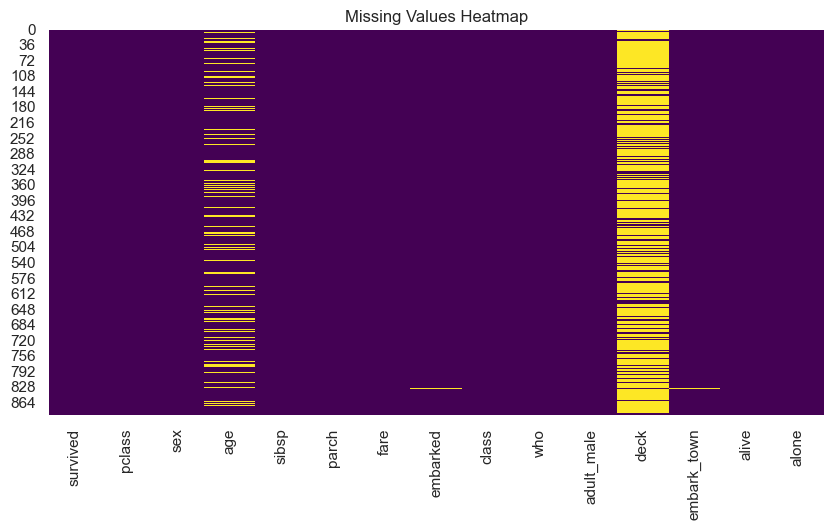

In [10]:
# Visualize missing data
plt.figure(figsize=(10,5))
sns.heatmap(titanic.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

In [11]:
# Fill missing ages with mean
titanic['age'].fillna(titanic['age'].mean(), inplace=True)

/var/folders/h1/9j9crw5d22927td5sp__xv9m0000gn/T/ipykernel_12599/4114628098.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic['age'].fillna(titanic['age'].mean(), inplace=True)


In [12]:
# Fill missing embarkation port with mode
titanic['embarked'].fillna(titanic['embarked'].mode()[0], inplace=True)

/var/folders/h1/9j9crw5d22927td5sp__xv9m0000gn/T/ipykernel_12599/3337752202.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic['embarked'].fillna(titanic['embarked'].mode()[0], inplace=True)


In [13]:
# Drop 'deck' since it has too many missing values
titanic.drop('deck', axis=1, inplace=True)

In [14]:
# Check again
titanic.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64

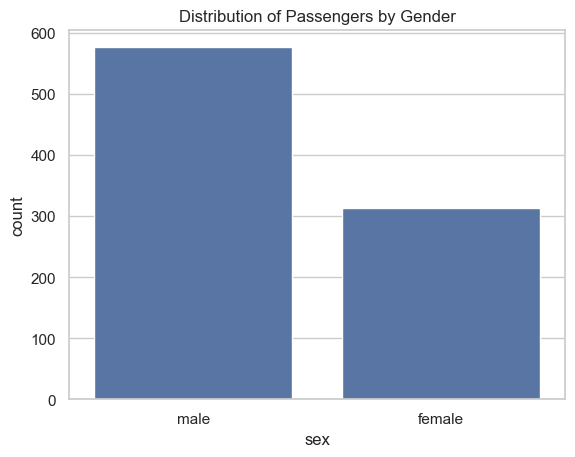

In [15]:
# Gender distribution
sns.countplot(x='sex', data=titanic)
plt.title("Distribution of Passengers by Gender")
plt.show()

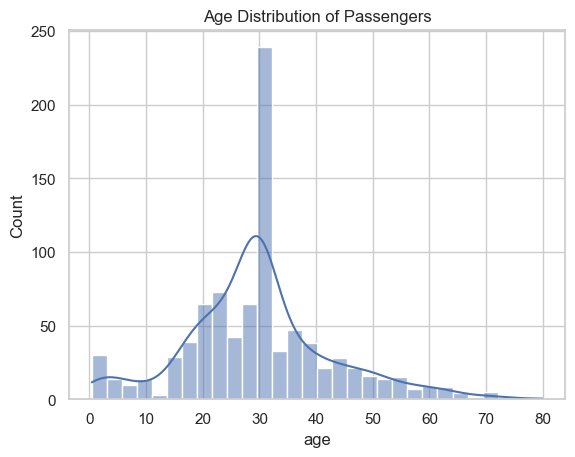

In [16]:
# Age distribution
sns.histplot(titanic['age'], bins=30, kde=True)
plt.title("Age Distribution of Passengers")
plt.show()

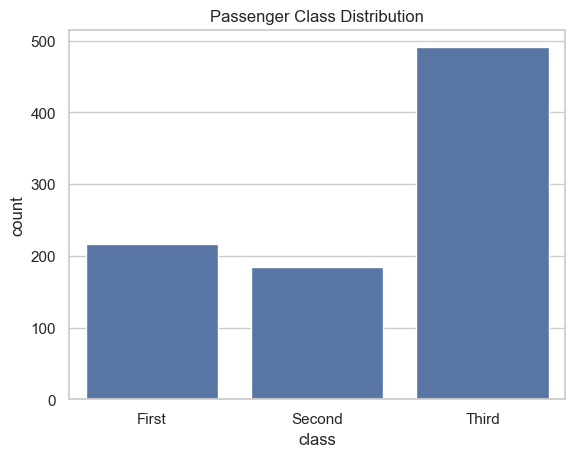

In [17]:
# Class distribution
sns.countplot(x='class', data=titanic)
plt.title("Passenger Class Distribution")
plt.show()

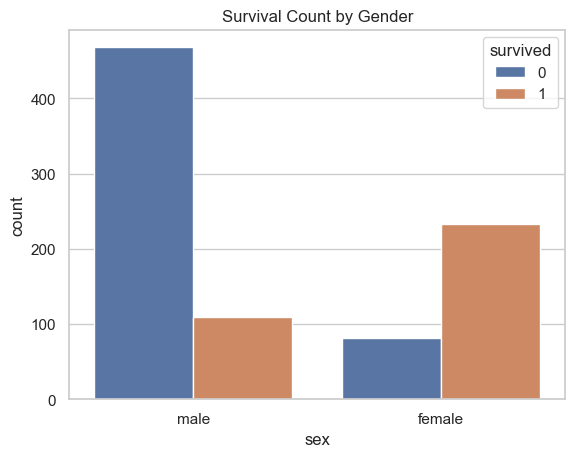

In [18]:
# Survival by gender
sns.countplot(x='sex', hue='survived', data=titanic)
plt.title("Survival Count by Gender")
plt.show()

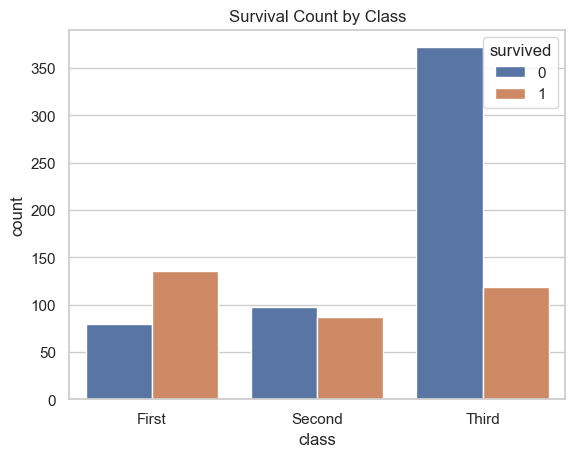

In [19]:
# Survival by class
sns.countplot(x='class', hue='survived', data=titanic)
plt.title("Survival Count by Class")
plt.show()

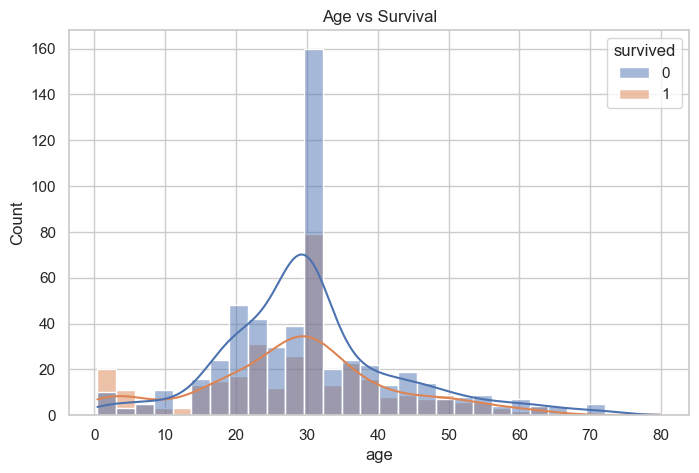

In [20]:
# Survival by age
plt.figure(figsize=(8,5))
sns.histplot(data=titanic, x='age', hue='survived', bins=30, kde=True)
plt.title("Age vs Survival")
plt.show()

In [21]:
# Convert 'sex' to numeric for correlation
titanic['sex_num'] = titanic['sex'].map({'male': 0, 'female': 1})

In [22]:
# Select only numeric columns
corr = titanic.corr(numeric_only=True)

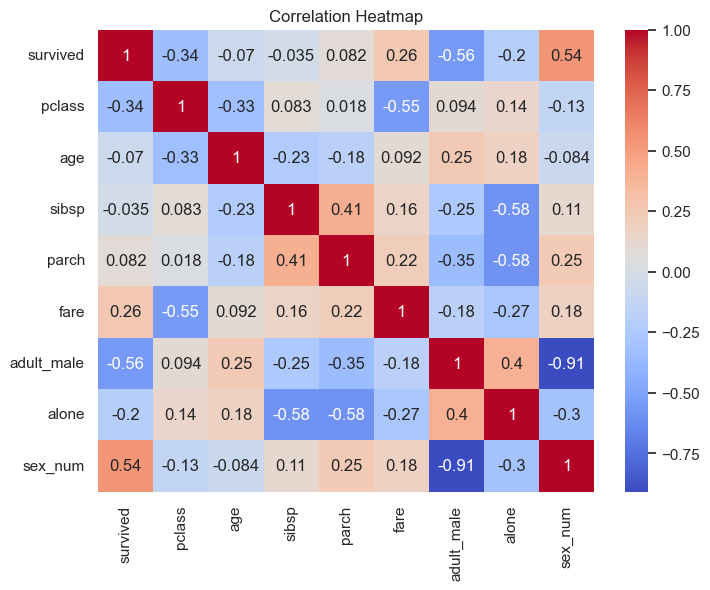

In [23]:
# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Key Insights

1. **Females survived more** than males — gender played a strong role.
2. **Higher-class passengers** (1st class) had higher survival chances.
3. **Younger passengers** survived more frequently than older ones.
4. **Fare paid** also shows a positive link with survival — richer passengers likely had better access to lifeboats.
5. Data cleaning was essential due to missing values in `age`, `deck`, and `embarked`.

---

This EDA gave us a clear understanding of what affects survival on the Titanic.  
In real-world data science projects, such analysis helps guide **feature selection** and **model building** decisions.
